<a href="https://colab.research.google.com/github/keishauliiaa-prog/PraktikDasarStatistikPython/blob/main/Latihan_2_Dasar_Statistik_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐍 Praktik Dasar Statistik pada Python

Statistik merupakan ilmu yang menerapkan
berbagai metode saintifik dalam proses
pengumpulan, analisis, interpretasi, serta
penyajian data.

Statistik dasar membantu memahami sifat data. Kita menggunakan Python dengan library:

* `nump`y → untuk perhitungan numerik

* `pandas` → untuk mempermudah analisis dataset

* `scipy.stats` → untuk analisis statistik dan scientific

* `matplotlib` / `seaborn` → visualisasi

In [ ]:
# Import library
import pandas as pd               # Untuk membuat dan mengelola DataFrame
import numpy as np                # Untuk perhitungan numerik
from scipy import stats           # Untuk mode, skew, IQR, dll
import matplotlib.pyplot as plt   # Untuk visualisasi
import seaborn as sns             # Untuk visualisasi lanjutan


# 1️⃣ Impot DataFrame

In [ ]:
# Dataset contoh
df = pd.DataFrame({
    "Order_Amount": [250, 400, 150, 500, 350, 420, 310, 280, 390, 450],  # nominal pesanan
    "Num_Items": [3, 5, 2, 6, 4, 5, 4, 3, 5, 6],                         # jumlah item
    "Customer_Age": [25, 34, 22, 45, 31, 37, 29, 28, 33, 40],            # umur pelanggan
    "Discount": [5, 10, 0, 15, 10, 12, 8, 5, 10, 15],                    # diskon %
    "Delivery_Time": [30, 45, 20, 60, 40, 50, 35, 30, 45, 55]            # waktu pengiriman (menit)
})
df  # Menampilkan DataFrame

,Order_Amount,Num_Items,Customer_Age,Discount,Delivery_Time
0,250,3,25,5,30
1,400,5,34,10,45
2,150,2,22,0,20
3,500,6,45,15,60
4,350,4,31,10,40
5,420,5,37,12,50
6,310,4,29,8,35
7,280,3,28,5,30
8,390,5,33,10,45
9,450,6,40,15,55


# 2️⃣ Measuring Central Tendency (`Ukuran Pemusatan`)

* `Mean` → Rata-rata

* `Median` → Nilai tengah

* `Mode` → Nilai yang paling sering muncul

In [ ]:
# Mean (rata-rata tiap kolom)
mean_values = df.mean()             # Mean
print("Mean:\n", mean_values)

# Median (nilai tengah tiap kolom)
median_values = df.median()         # Median
print("\nMedian:\n", median_values)

# Mode (nilai paling sering muncul tiap kolom)
mode_values = df.mode().iloc[0]     # Mode pertama tiap kolom
print("\nMode:\n", mode_values)

Mean:
 Order_Amount     350.0
Num_Items          4.3
Customer_Age      32.4
Discount           9.0
Delivery_Time     41.0
dtype: float64

Median:
 Order_Amount     370.0
Num_Items          4.5
Customer_Age      32.0
Discount          10.0
Delivery_Time     42.5
dtype: float64

Mode:
 Order_Amount     150.0
Num_Items          5.0
Customer_Age      22.0
Discount          10.0
Delivery_Time     30.0
Name: 0, dtype: float64


# 3️⃣ Measuring Dispersion (`Ukuran Penyebaran`)

* `Range` → Selisih max-min

* `Interquartile Range (IQR)` → Q3-Q1, mengukur sebaran tengah

* `Variance` → Rata-rata kuadrat deviasi dari mean

* `Standard` Deviation → Akar variansi

In [ ]:
# Range (selisih max-min tiap kolom)
range_values = df.max() - df.min()  # Range
print("\nRange:\n", range_values)

# Interquartile Range (IQR tiap kolom)
iqr_values = df.apply(stats.iqr)  # IQR
print("\nIQR:\n", iqr_values)

# Variance (variansi sampel tiap kolom)
variance_values = df.var()  # Variance
print("\nVariance:\n", variance_values)

# Standard Deviation (standar deviasi tiap kolom)
std_dev_values = df.std()  # Std Dev
print("\nStandard Deviation:\n", std_dev_values)



Range:
 Order_Amount     350
Num_Items          4
Customer_Age      23
Discount          15
Delivery_Time     40
dtype: int64

IQR:
 Order_Amount     127.50
Num_Items          1.75
Customer_Age       8.00
Discount           5.75
Delivery_Time     17.50
dtype: float64

Variance:
 Order_Amount     10888.888889
Num_Items            1.788889
Customer_Age        48.488889
Discount            22.000000
Delivery_Time      154.444444
dtype: float64

Standard Deviation:
 Order_Amount     104.349839
Num_Items          1.337494
Customer_Age       6.963396
Discount           4.690416
Delivery_Time     12.427568
dtype: float64


# 4️⃣ Measuring Asymmetry (`Skewness` / `Distribusi`)

* Distribusi `Simetris` → `Mean` ≈ `Median` ≈ `Mode`

* Distribusi `Right-skewed` → Tail ke `kanan` (nilai besar lebih ekstrem)

* Distribusi `Left-skewed` → Tail ke `kiri` (nilai kecil lebih ekstrem)

In [ ]:
# Skewness (kemiringan distribusi tiap kolom)
skew_values = df.skew()  # Skewness
print("\nSkewness:\n", skew_values)

# Interpretasi distribusi tiap kolom
for col in df.columns:
    if skew_values[col] > 0:
        print(f"{col}: Right-skewed")  # Tail ke kanan
    elif skew_values[col] < 0:
        print(f"{col}: Left-skewed")   # Tail ke kiri
    else:
        print(f"{col}: Symmetric")     # Simetris



Skewness:
 Order_Amount    -0.550053
Num_Items       -0.334360
Customer_Age     0.363496
Discount        -0.533002
Delivery_Time   -0.121568
dtype: float64
Order_Amount: Left-skewed
Num_Items: Left-skewed
Customer_Age: Right-skewed
Discount: Left-skewed
Delivery_Time: Left-skewed


💡 Visualisasi

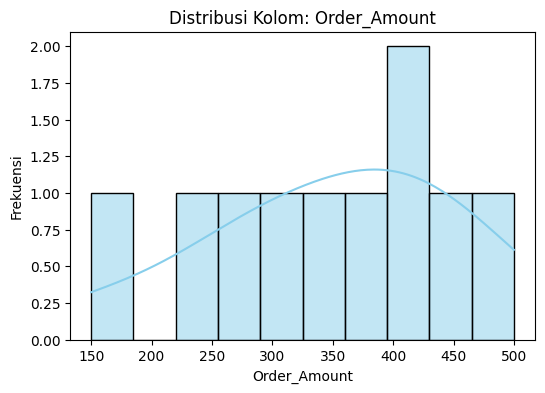

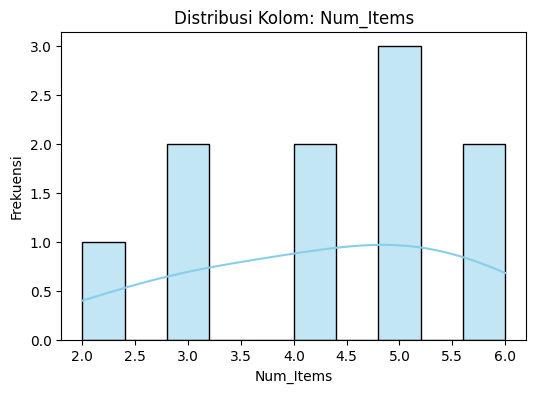

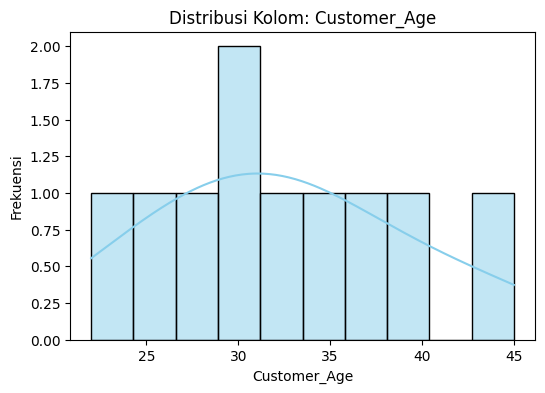

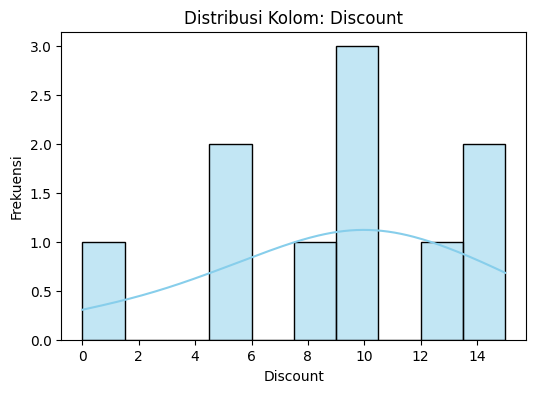

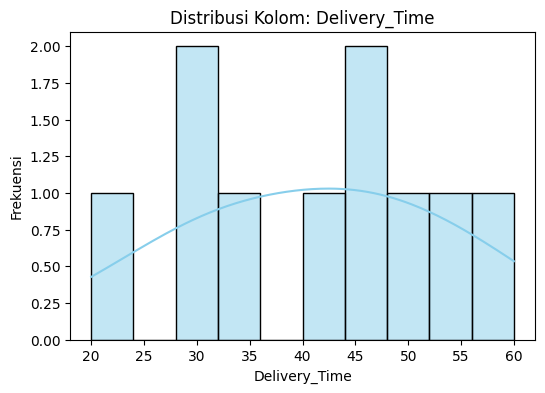

In [ ]:
# Grafik distribusi tiap kolom
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue', bins=10)  # Histogram + density plot
    plt.title(f"Distribusi Kolom: {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()

# 5️⃣ Data Relationship (`Hubungan Data`)

`Correlation` → Kekuatan dan arah hubungan linear

`Covariance` → Variabilitas bersama antara dua variabel

In [ ]:
# Correlation matrix (hubungan linear antar kolom)
correlation = df.corr()  # Correlation
print("\nCorrelation:\n", correlation)

# Covariance matrix (variabilitas bersama antar kolom)
covariance = df.cov()  # Covariance
print("\nCovariance:\n", covariance)


Correlation:
                Order_Amount  Num_Items  Customer_Age  Discount  Delivery_Time
Order_Amount       1.000000   0.979217      0.969469  0.980704       0.989604
Num_Items          0.979217   1.000000      0.952023  0.974131       0.982646
Customer_Age       0.969469   0.952023      1.000000  0.952540       0.983510
Discount           0.980704   0.974131      0.952540  1.000000       0.981674
Delivery_Time      0.989604   0.982646      0.983510  0.981674       1.000000

Covariance:
                Order_Amount   Num_Items  Customer_Age    Discount  \
Order_Amount   10888.888889  136.666667    704.444444  480.000000   
Num_Items        136.666667    1.788889      8.866667    6.111111   
Customer_Age     704.444444    8.866667     48.488889   31.111111   
Discount         480.000000    6.111111     31.111111   22.000000   
Delivery_Time   1283.333333   16.333333     85.111111   57.222222   

               Delivery_Time  
Order_Amount     1283.333333  
Num_Items          16.3333

💡 Visualisasi

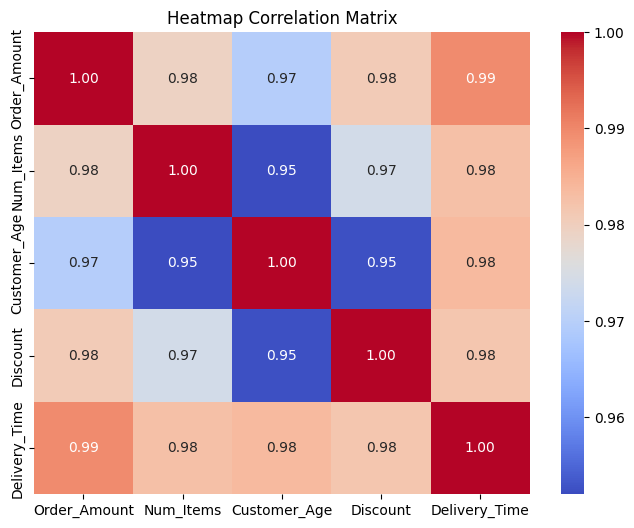

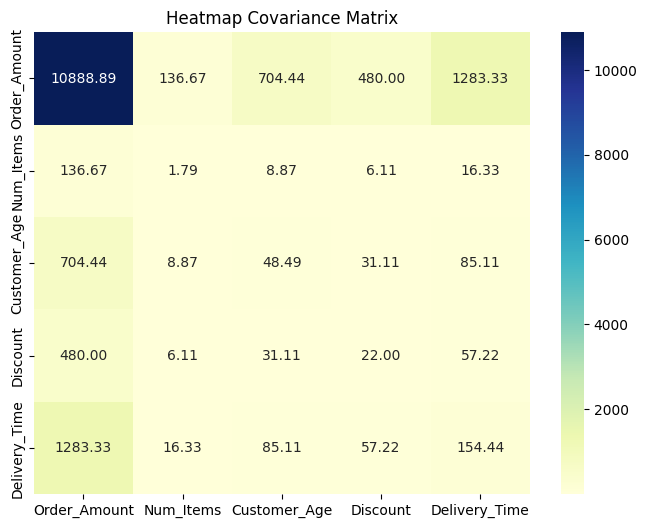

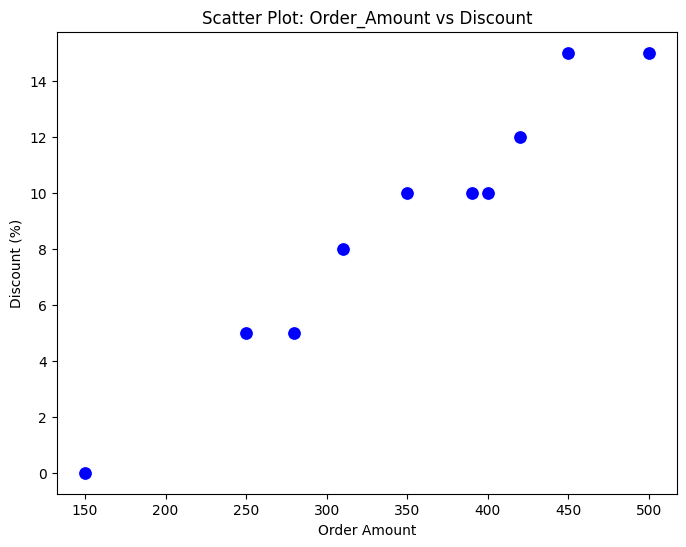

In [ ]:
# Heatmap Correlation
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")  # annot=True menampilkan angka
plt.title("Heatmap Correlation Matrix")
plt.show()

# Heatmap Covariance
plt.figure(figsize=(8,6))
sns.heatmap(covariance, annot=True, cmap="YlGnBu", fmt=".2f")  # fmt=".2f" 2 desimal
plt.title("Heatmap Covariance Matrix")
plt.show()

# 🔹 Scatter Plot Order_Amount vs Discount (titik biru)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Order_Amount", y="Discount", color='blue', s=100)  # semua titik biru
plt.title("Scatter Plot: Order_Amount vs Discount")
plt.xlabel("Order Amount")
plt.ylabel("Discount (%)")
plt.show()

# 6️⃣ Summary Statistics

In [ ]:
# Summary Statistics (Ringkasan Statistik DataFrame)
summary_stats = df.describe()  # Menghitung count, mean, std, min, Q1, median, Q3, max
print("Summary Statistics:\n", summary_stats)

Summary Statistics:
        Order_Amount  Num_Items  Customer_Age   Discount  Delivery_Time
count     10.000000  10.000000     10.000000  10.000000      10.000000
mean     350.000000   4.300000     32.400000   9.000000      41.000000
std      104.349839   1.337494      6.963396   4.690416      12.427568
min      150.000000   2.000000     22.000000   0.000000      20.000000
25%      287.500000   3.250000     28.250000   5.750000      31.250000
50%      370.000000   4.500000     32.000000  10.000000      42.500000
75%      415.000000   5.000000     36.250000  11.500000      48.750000
max      500.000000   6.000000     45.000000  15.000000      60.000000


# 🔹 Penjelasan:

* `pd.DataFrame(data)` → membuat tabel data berbasis kolom dan baris.

* `df.head(n)` → menampilkan n baris teratas (default 5).

* `df.info()` → menampilkan tipe data dan jumlah data tiap kolom.

* `df.describe()` → ringkasan statistik dasar: count, mean, std, min, 25%, 50%, 75%, max.

* `np.mean(data)` / `np.median(data)` / `stats.mode(data)` → menghitung ukuran pemusatan data.

* `np.var(data)` / `np.std(data)` → menghitung variansi dan standar deviasi.

* `stats.iqr(data)` → menghitung interquartile range.

* `df.corr()` → matriks korelasi antar kolom numerik.

* `df.cov()` → matriks kovariansi antar kolom numerik.

* `sns.histplot(df['col'], kde=True)` → histogram + density plot untuk satu kolom.

* `sns.scatterplot(data=df, x='col1', y='col2', color='blue')` → scatter plot antar kolom.

* `sns.heatmap(df.corr(), annot=True, cmap='coolwarm')` → heatmap matriks korelasi dengan angka.